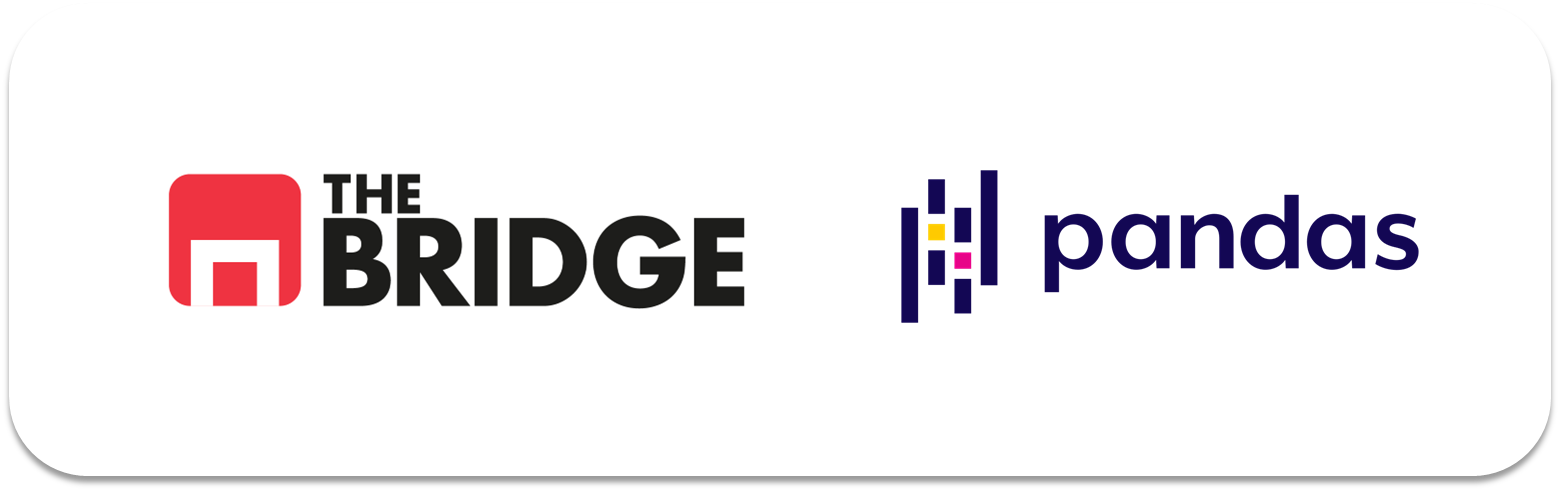


# Introducción a Pandas

Pandas es la librería de Python más popular para el análisis y la manipulación de datos. Proporciona estructuras de datos y herramientas de análisis de alto rendimiento y fáciles de usar, construidas sobre NumPy.

El nombre "pandas" deriva de "panel data" (datos de panel), un término de econometría para datasets estructurados multidimensionales.

**Documentación oficial:** https://pandas.pydata.org/docs/

## ¿Por qué Pandas?

### Ventajas:
1. **Manejo sencillo de datos**: trabajar con datos estructurados de forma intuitiva
2. **Limpieza de datos**: gestionar valores faltantes, duplicados e inconsistencias
3. **Transformación de datos**: reestructurar, combinar (merge/join) y crear pivotes fácilmente
4. **Series temporales**: soporte integrado para datos temporales
5. **Integración**: funciona de forma fluida con NumPy, Matplotlib y otras librerías
6. **Operaciones de E/S (I/O)**: leer/escribir CSV, Excel, SQL, JSON y más

### Características clave:
- Estructuras de datos `DataFrame` y `Series`
- Alineación inteligente de datos
- Agrupación y agregación flexibles
- Visualización integrada
- Indexado y selección eficientes

## Cuándo usar Pandas vs NumPy

Entender cuándo usar cada librería es importante para un análisis de datos eficiente:

### Usa NumPy cuando:
- Trabajas con arrays y matrices numéricas
- Necesitas operaciones matemáticas muy rápidas
- Los datos son homogéneos (todos del mismo tipo)
- Trabajas con datos numéricos multidimensionales
- La eficiencia en memoria es crítica

### Usa Pandas cuando:
- Trabajas con datos tabulares (filas y columnas)
- Necesitas manejar tipos de datos mixtos
- Trabajas con datos etiquetados (nombres de columnas, índices)
- Necesitas herramientas de limpieza y transformación
- Lees/escribes datos desde ficheros (CSV, Excel, SQL)
- Haces operaciones `groupby` y agregaciones
- Trabajas con series temporales

### Buena práctica:
**¡Usa ambas a la vez!** Pandas está construido sobre NumPy y puedes convertir fácilmente entre ambos:
- DataFrame → NumPy: `df.values` o `df.to_numpy()`
- NumPy → DataFrame: `pd.DataFrame(array)`

**Flujo típico:** cargar datos con Pandas → limpiar con Pandas → convertir a NumPy para operaciones numéricas → volver a Pandas para presentar resultados

In [ ]:
import pandas as pd
import numpy as np

# Example: Pandas for structured data
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'Salary': [50000, 60000, 55000]
})
print("Pandas DataFrame (mixed types):")
print(df)
print("\nData types:", df.dtypes.tolist())

# Convert to NumPy for numerical operations
ages_array = df['Age'].values
salaries_array = df['Salary'].values

print("\nNumPy arrays (numerical operations):")
print("Ages:", ages_array)
print("Salaries:", salaries_array)

# Perform NumPy operations
age_mean = np.mean(ages_array)
salary_normalized = (salaries_array - np.mean(salaries_array)) / np.std(salaries_array)

print("\nResults:")
print(f"Average age: {age_mean}")
print(f"Normalized salaries: {salary_normalized}")

# Convert back to Pandas
df['Salary_Normalized'] = salary_normalized
print("\nBack to Pandas with new column:")
print(df)

## Estructuras de datos principales

Pandas tiene dos estructuras de datos principales:

1. **Series**: array unidimensional etiquetado (como una columna)
2. **DataFrame**: estructura bidimensional etiquetada (como una tabla)

**Documentación:** https://pandas.pydata.org/docs/user_guide/dsintro.html

## `Series` en Pandas

Una `Series` es un array unidimensional con etiquetas (índice).

In [ ]:
# Create a Series from a list
series_from_list = pd.Series([10, 20, 30, 40, 50])
print("Series from list:")
print(series_from_list)
print("\nData type:", type(series_from_list))

# Create a Series with custom index
series_with_index = pd.Series([10, 20, 30, 40, 50], 
                               index=['a', 'b', 'c', 'd', 'e'])
print("\nSeries with custom index:")
print(series_with_index)

# Create a Series from a dictionary
data_dict = {'apple': 5, 'banana': 3, 'orange': 8}
series_from_dict = pd.Series(data_dict)
print("\nSeries from dictionary:")
print(series_from_dict)

In [ ]:
# Series attributes and methods
series = pd.Series([10, 20, 30, 40, 50], index=['a', 'b', 'c', 'd', 'e'])

print("Values:", series.values)
print("Index:", series.index)
print("Shape:", series.shape)
print("Size:", series.size)
print("Data type:", series.dtype)

# Accessing elements
print("\nAccess by index label:", series['c'])
print("Access by position:", series[2])
print("Access multiple:", series[['a', 'c', 'e']])

# Basic statistics
print("\nMean:", series.mean())
print("Sum:", series.sum())
print("Max:", series.max())
print("Min:", series.min())

## `DataFrame` en Pandas

Un `DataFrame` es una estructura de datos etiquetada en 2 dimensiones, con columnas que pueden ser de distintos tipos. Piensa en él como una hoja de cálculo o una tabla SQL.

In [ ]:
# Create DataFrame from dictionary
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [25, 30, 35, 28, 32],
    'City': ['New York', 'London', 'Paris', 'Tokyo', 'Berlin'],
    'Salary': [50000, 60000, 55000, 65000, 58000]
}

df = pd.DataFrame(data)
print("DataFrame from dictionary:")
print(df)

# Create DataFrame from list of lists
data_list = [
    ['Alice', 25, 'New York', 50000],
    ['Bob', 30, 'London', 60000],
    ['Charlie', 35, 'Paris', 55000]
]
df_from_list = pd.DataFrame(data_list, 
                             columns=['Name', 'Age', 'City', 'Salary'])
print("\nDataFrame from list:")
print(df_from_list)

In [ ]:
# DataFrame attributes and methods
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nIndex:", df.index.tolist())
print("\nData types:\n", df.dtypes)
print("\nInfo:")
df.info()
print("\nFirst 3 rows:")
print(df.head(3))
print("\nLast 2 rows:")
print(df.tail(2))
print("\nDescriptive statistics:")
print(df.describe())

## El índice en Pandas (`index`)

En Pandas, el **índice** es la estructura que identifica cada fila de un DataFrame. No es una columna normal, pero es clave para seleccionar, filtrar y organizar datos de forma eficiente.

Puedes ver el índice actual con:

In [ ]:
df.index


Por defecto, Pandas crea un índice numérico automático (0, 1, 2, ...), pero podemos cambiarlo para usar una columna como identificador de filas.

Para usar una columna como índice se utiliza `set_index()`:

In [ ]:
df_indexed = df.set_index('Name')
df_indexed

Ahora la columna `Name` se convierte en el índice del DataFrame, y deja de ser una columna normal.


Si en algún momento queremos volver al índice numérico por defecto, usamos `reset_index()`:

In [ ]:
df_reset = df_indexed.reset_index()
df_reset


Esto convierte el índice de nuevo en una columna normal y restaura el índice automático.

También es importante entender que el índice no tiene por qué ser único ni numérico, puede ser texto, fechas o cualquier otro tipo de etiqueta, lo que lo hace muy potente para análisis de datos.

## Selección de datos

Pandas ofrece múltiples formas de seleccionar y acceder a los datos:

**Documentación:** https://pandas.pydata.org/docs/user_guide/indexing.html

In [ ]:
# Create sample DataFrame
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [25, 30, 35, 28, 32],
    'City': ['New York', 'London', 'Paris', 'Tokyo', 'Berlin'],
    'Salary': [50000, 60000, 55000, 65000, 58000]
})

# Select single column (returns Series)
print("Select 'Name' column:")
print(df['Name'])
print("\nType:", type(df['Name']))

# Select multiple columns (returns DataFrame)
print("\nSelect multiple columns:")
print(df[['Name', 'Age']])

# Select rows by index position (iloc)
print("\nFirst row (iloc):")
print(df.iloc[0])

print("\nFirst 3 rows:")
print(df.iloc[0:3])

# Select rows by index label (loc)
print("\nSelect by label (loc):")
print(df.loc[1:3, ['Name', 'City']])

# Select specific cells
print("\nSelect specific cell:")
print(df.loc[2, 'Name'])

In [ ]:
# Boolean indexing (filtering)
print("People older than 30:")
print(df[df['Age'] > 30])

print("\nPeople in New York or London:")
print(df[df['City'].isin(['New York', 'London'])])

# Multiple conditions (AND)
print("\nAge > 25 AND Salary > 55000:")
print(df[(df['Age'] > 25) & (df['Salary'] > 55000)])

# Multiple conditions (OR)
print("\nAge < 30 OR Salary > 60000:")
print(df[(df['Age'] < 30) | (df['Salary'] > 60000)])

# String methods
print("\nNames starting with 'A' or 'B':")
print(df[df['Name'].str.startswith(('A', 'B'))])

## Entender `loc` vs `iloc` vs `[]` — en profundidad

Uno de los puntos que más confunden al empezar con Pandas es la diferencia entre `loc`, `iloc` y el indexado con corchetes `[]`. Vamos a dejarlo claro:

### Tres formas de seleccionar datos:

1. **`[]` (corchetes)**: comportamiento mixto, puede confundir
2. **`.loc[]`**: indexado por **etiqueta** (índice explícito)
3. **`.iloc[]`**: indexado por **posición** (posición entera)

**Buena práctica:** usa siempre `.loc[]` o `.iloc[]` para ser explícito y evitar confusiones.

In [ ]:
# Create a DataFrame with INTEGER index to show the confusion
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [25, 30, 35, 28, 32],
    'City': ['NYC', 'London', 'Paris', 'Tokyo', 'Berlin']
}, index=[10, 20, 30, 40, 50])  # Non-sequential integer index!

print("DataFrame with custom integer index:")
print(df)
print("\nIndex:", df.index.tolist())

In [ ]:
# THE CONFUSION: What does df[10] mean?
# Is it position 10 or label 10?

# Using bracket notation with integer index
try:
    print("df[10] - ERROR! Tries to use position 10 (doesn't exist)")
    print(df[10])
except KeyError as e:
    print(f"KeyError: {e}")

# Slicing with brackets uses POSITION (implicit index)
print("\ndf[0:2] - Uses POSITION (first 2 rows):")
print(df[0:2])

# But selecting a single value would try to use LABEL
# This is CONFUSING!

In [ ]:
# SOLUTION 1: Use .loc[] for LABEL-based selection
print("Using .loc[] - LABEL-based (uses index values):")
print("\ndf.loc[10] - Gets row with index label 10:")
print(df.loc[10])

print("\ndf.loc[10:30] - Slice by labels (INCLUDES endpoint!):")
print(df.loc[10:30])

print("\ndf.loc[10, 'Name'] - Get specific cell:")
print(df.loc[10, 'Name'])

print("\ndf.loc[[10, 30, 50], ['Name', 'Age']] - Multiple rows and columns:")
print(df.loc[[10, 30, 50], ['Name', 'Age']])

In [ ]:
# SOLUTION 2: Use .iloc[] for POSITION-based selection
print("Using .iloc[] - POSITION-based (like NumPy arrays):")
print("\ndf.iloc[0] - Gets FIRST row (position 0):")
print(df.iloc[0])

print("\ndf.iloc[0:2] - Slice by position (EXCLUDES endpoint):")
print(df.iloc[0:2])

print("\ndf.iloc[0, 1] - Get cell at position [0, 1]:")
print(df.iloc[0, 1])

print("\ndf.iloc[[0, 2, 4], [0, 1]] - Multiple positions:")
print(df.iloc[[0, 2, 4], [0, 1]])

### Resumen de diferencias clave

| Característica | `.loc[]` | `.iloc[]` | `[]` |
|---------|----------|-----------|------|
| **Tipo de selección** | Por etiqueta | Por posición | Mixto (¡confuso!) |
| **Extremo del slice** | **Incluido** | **Excluido** | Excluido |
| **Funciona con** | Etiquetas del índice | Posiciones enteras | Depende |
| **Valor único** | `df.loc[etiqueta]` | `df.iloc[pos]` | `df[col]` (solo columnas) |
| **Slices** | `df.loc[10:30]` | `df.iloc[0:2]` | `df[0:2]` (posición) |
| **¿Recomendado?** | ✅ Sí, explícito | ✅ Sí, explícito | ⚠️ Con cuidado |

### Regla de oro

**Para seleccionar filas, prioriza `.loc[]` o `.iloc[]` frente a `[]`.**

- Usa `.loc[]` cuando conozcas las etiquetas del índice
- Usa `.iloc[]` cuando te importen las posiciones
- Usa `[]` sobre todo para seleccionar columnas: `df['columna']`

In [ ]:
# Practical example: Why explicit is better

# Bad practice (confusing):
df_subset = df[0:2]  # Uses position
# df_value = df[10]  # Would cause error!

# Good practice (explicit and clear):
df_subset_loc = df.loc[10:30]  # Clear: using labels
df_subset_iloc = df.iloc[0:2]  # Clear: using positions

print("Using .loc[] (labels 10:30, includes 30):")
print(df_subset_loc)

print("\nUsing .iloc[] (positions 0:2, excludes 2):")
print(df_subset_iloc)

# Both are explicit about what they're doing!

## Gestión de valores faltantes

Los datos del mundo real suelen contener valores faltantes. Pandas proporciona herramientas para manejarlos:

**Documentación:** https://pandas.pydata.org/docs/user_guide/missing_data.html

### Entender `None` vs `NaN`

Pandas usa dos valores de Python para representar datos faltantes:
- **`None`**: objeto singleton de Python (suele aparecer en arrays `object`)
- **`NaN`**: "Not a Number", un valor especial de coma flotante (suele aparecer en arrays numéricos)

**Importante:** Pandas trata ambos como equivalentes para indicar valores faltantes, pero internamente existen diferencias.

In [ ]:
# Understanding None vs NaN

# None - Python object
vals_none = pd.Series([1, None, 3, 4])
print("Series with None:")
print(vals_none)
print("Data type:", vals_none.dtype)  # object dtype

# NaN - Numeric missing value
vals_nan = pd.Series([1, np.nan, 3, 4])
print("\nSeries with NaN:")
print(vals_nan)
print("Data type:", vals_nan.dtype)  # float64 dtype

# Pandas converts between them automatically
print("\nAutomatic conversion:")
print("None in numeric context becomes NaN:", vals_none.mean())

### Conversión de tipos con valores faltantes

Cuando introduces valores faltantes, Pandas puede convertir automáticamente los tipos de datos:

| Tipo original | Valor faltante añadido | Tipo resultante | Representación de NA |
|--------------|-------------------------|----------------|----------------------|
| `int` | `np.nan` o `None` | `float64` | `np.nan` |
| `float` | `np.nan` o `None` | `float64` | `np.nan` |
| `bool` | `np.nan` o `None` | `object` | `None` o `np.nan` |
| `object` | `np.nan` o `None` | `object` | `None` o `np.nan` |

**Idea clave:** las series/arrays enteros se convierten a `float` cuando aparece `NaN`, porque en NumPy no existe un "NaN entero".

In [ ]:
# Type conversion example
original = pd.Series([1, 2, 3, 4], dtype='int64')
print("Original integer Series:")
print(original)
print("Data type:", original.dtype)

# Add a missing value
original_with_nan = original.copy()
original_with_nan[2] = np.nan
print("\nAfter adding NaN:")
print(original_with_nan)
print("Data type:", original_with_nan.dtype)  # Converted to float64!

# Boolean conversion
bool_series = pd.Series([True, False, True])
print("\nOriginal boolean Series:")
print(bool_series)
print("Data type:", bool_series.dtype)

bool_series[1] = None
print("\nAfter adding None:")
print(bool_series)
print("Data type:", bool_series.dtype)  # Converted to object!

### Detección de valores faltantes

Usa `isnull()` o `notnull()` para detectar valores faltantes:

In [ ]:
# Create DataFrame with missing values
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [25, np.nan, 35, 28, np.nan],
    'City': ['New York', 'London', None, 'Tokyo', 'Berlin'],
    'Salary': [50000, 60000, None, 65000, 58000]
})

print("DataFrame with missing values:")
print(df)

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nAny missing values?:", df.isnull().any().any())

# Visualize missing data
print("\nMissing data mask:")
print(df.isnull())

In [ ]:
# Using boolean masks to filter
print("Original DataFrame:")
print(df)

# Get rows with NO missing values
print("\nRows with no missing values:")
print(df[df.notnull().all(axis=1)])

# Get rows with ANY missing values
print("\nRows with any missing values:")
print(df[df.isnull().any(axis=1)])

# Get non-null values from a specific column
print("\nNon-null Ages:")
print(df[df['Age'].notnull()])

### Eliminar valores faltantes

El método `dropna()` elimina filas o columnas con valores faltantes:

In [ ]:
# Drop rows with any missing values
df_dropped = df.dropna()
print("After dropping rows with NaN:")
print(df_dropped)

# Drop columns with any missing values
df_dropped_cols = df.dropna(axis=1)
print("\nAfter dropping columns with NaN:")
print(df_dropped_cols)

# Drop rows only if all values are missing
df_dropped_all = df.dropna(how='all')
print("\nAfter dropping rows where all values are NaN:")
print(df_dropped_all)

# Drop rows with missing values in specific columns
df_dropped_subset = df.dropna(subset=['Age'])
print("\nAfter dropping rows with NaN in 'Age':")
print(df_dropped_subset)

### `dropna()` avanzado: parámetro `thresh`

El parámetro `thresh` es muy útil en la práctica: especifica el **número mínimo de valores no nulos** necesarios para conservar una fila/columna:

In [ ]:
# Create DataFrame with varying amounts of missing data
df_messy = pd.DataFrame({
    'A': [1, 2, np.nan, np.nan, 5],
    'B': [np.nan, 2, 3, np.nan, 5],
    'C': [1, np.nan, np.nan, 4, 5],
    'D': [1, 2, 3, 4, 5]
})

print("Messy DataFrame:")
print(df_messy)
print("\nMissing values per row:")
print(df_messy.isnull().sum(axis=1))

# Keep rows with at least 3 non-null values
df_thresh = df_messy.dropna(thresh=3)
print("\nKeep rows with at least 3 non-null values:")
print(df_thresh)

# Keep rows with at least 75% non-null values
min_count = int(len(df_messy.columns) * 0.75)
df_percent = df_messy.dropna(thresh=min_count)
print(f"\nKeep rows with at least {min_count} non-null values (75% of {len(df_messy.columns)} columns):")
print(df_percent)

In [ ]:
# thresh with axis=1 (columns)
print("Original DataFrame:")
print(df_messy)
print("\nMissing values per column:")
print(df_messy.isnull().sum())

# Keep columns with at least 4 non-null values
df_thresh_cols = df_messy.dropna(axis=1, thresh=4)
print("\nKeep columns with at least 4 non-null values:")
print(df_thresh_cols)

### Rellenar valores faltantes

En lugar de eliminar filas/columnas, puedes rellenar valores faltantes con `fillna()`:

In [ ]:
# Create sample data for filling examples
df_fill = pd.DataFrame({
    'A': [1, np.nan, 3, np.nan, 5],
    'B': [np.nan, 2, np.nan, 4, 5],
    'C': [1, 2, 3, 4, 5]
})

print("Original DataFrame:")
print(df_fill)

# Fill missing values with a constant
df_filled = df_fill.fillna(0)
print("\nFill NaN with 0:")
print(df_filled)

# Fill with different values per column
df_filled_dict = df_fill.fillna({'A': df_fill['A'].mean(), 
                                 'B': df_fill['B'].median()})
print("\nFill with different values per column:")
print(df_filled_dict)

### Relleno hacia delante y hacia atrás

Para series temporales o datos ordenados, puedes propagar valores hacia delante o hacia atrás:

- **Forward fill (`ffill`)**: usa el último valor válido
- **Backward fill (`bfill`)**: usa el siguiente valor válido

In [ ]:
# Create a Series to demonstrate fill methods clearly
data = pd.Series([1, np.nan, np.nan, 4, np.nan, np.nan, 7], 
                 index=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

print("Original Series:")
print(data)

# Forward fill - propagate last valid value forward
print("\nForward fill (ffill):")
print(data.fillna(method='ffill'))

# Backward fill - propagate next valid value backward
print("\nBackward fill (bfill):")
print(data.fillna(method='bfill'))

# Compare all three
print("\n=== Comparison ===")
comparison = pd.DataFrame({
    'Original': data,
    'Forward Fill': data.fillna(method='ffill'),
    'Backward Fill': data.fillna(method='bfill')
})
print(comparison)

In [ ]:
# Forward and backward fill with DataFrames
df_dates = pd.DataFrame({
    'Date': pd.date_range('2024-01-01', periods=7, freq='D'),
    'Sales': [100, np.nan, np.nan, 150, np.nan, 180, 200],
    'Customers': [10, 12, np.nan, np.nan, 15, np.nan, 20]
})

print("Sales data with missing values:")
print(df_dates)

# Forward fill
print("\nForward fill:")
print(df_dates.fillna(method='ffill'))

# Backward fill
print("\nBackward fill:")
print(df_dates.fillna(method='bfill'))

# Limit the number of consecutive fills
print("\nForward fill with limit=1 (only fill 1 consecutive NaN):")
print(df_dates.fillna(method='ffill', limit=1))

### Interpolación para datos numéricos

Para datos numéricos, la interpolación puede ofrecer un rellenado más sofisticado:

In [ ]:
# Interpolation example
df_interp = pd.DataFrame({
    'Value': [1, np.nan, np.nan, 4, np.nan, 6, np.nan, np.nan, 9]
})

print("Original data:")
print(df_interp)

# Linear interpolation (default)
df_interp['Linear'] = df_interp['Value'].interpolate()
print("\nLinear interpolation:")
print(df_interp)

# Polynomial interpolation
df_interp['Polynomial'] = df_interp['Value'].interpolate(method='polynomial', order=2)
print("\nPolynomial interpolation:")
print(df_interp)

### Consejos prácticos para tratar valores faltantes

**Cuándo usar cada enfoque:**

1. **`dropna()`**: úsalo cuando:
   - Los datos faltantes sean pocos (< 5% de las filas)
   - Los faltantes sean aleatorios (MCAR - Missing Completely At Random)
   - Te siga quedando suficiente información tras eliminar

2. **`fillna(0)` o constante**: úsalo cuando:
   - Cero/constante tenga sentido de negocio (p. ej. sin ventas = 0)
   - Estés creando variables indicadoras

3. **`fillna(media/mediana)`**: úsalo cuando:
   - El dato sea numérico
   - Quieras preservar la distribución
   - Media para distribuciones normales, mediana para sesgadas

4. **Forward/Backward fill**: úsalo cuando:
   - Los datos sean una serie temporal
   - Los valores no cambien bruscamente
   - El orden sea importante

5. **`interpolate()`**: úsalo cuando:
   - El dato sea numérico y “suave”
   - Esperes cambios graduales
   - Sea una serie temporal con intervalos regulares

**Ejemplo de árbol de decisión:**
```
¿Es una serie temporal?
├─ Sí → Usa ffill/bfill o interpolate()
└─ No → ¿Hay < 5% de faltantes?
    ├─ Sí → Usa dropna()
    └─ No → Usa fillna(media/mediana) o imputación específica del dominio
```

In [ ]:
# Practical example: Complete workflow
print("=== Real-world Missing Data Workflow ===\n")

# 1. Create realistic messy data
df_real = pd.DataFrame({
    'Date': pd.date_range('2024-01-01', periods=10, freq='D'),
    'Product': ['A', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'B'],
    'Sales': [100, 150, np.nan, 180, 120, np.nan, np.nan, 200, 110, np.nan],
    'Returns': [5, np.nan, 3, 4, np.nan, 2, 1, np.nan, 2, 3]
})

print("Original data:")
print(df_real)
print(f"\nMissing data summary:")
print(df_real.isnull().sum())

# 2. Analyze missing patterns
missing_pct = (df_real.isnull().sum() / len(df_real)) * 100
print(f"\nMissing percentage:")
print(missing_pct)

# 3. Apply appropriate strategy
df_clean = df_real.copy()

# Sales: use forward fill (time series assumption)
df_clean['Sales'] = df_clean['Sales'].fillna(method='ffill')

# Returns: use median (sporadic missing, numerical)
df_clean['Returns'] = df_clean['Returns'].fillna(df_clean['Returns'].median())

print("\nCleaned data:")
print(df_clean)

# 4. Verify no missing values remain
print(f"\nRemaining missing values:")
print(df_clean.isnull().sum())

## Unir y combinar DataFrames (merge/join)

Combinar datos de múltiples fuentes es una tarea fundamental en análisis de datos. Pandas ofrece herramientas potentes para hacer merges y joins de DataFrames, de forma similar a las operaciones de una base de datos SQL.

**Documentación:** https://pandas.pydata.org/docs/user_guide/merging.html

### Entender los tipos de joins

Antes de entrar al código, conviene entender los distintos tipos de join y cuándo usar cada uno:

**1. Join uno a uno (One-to-One)**: cada clave aparece una sola vez en ambos DataFrames
- Ejemplo: combinar datos personales de empleados con datos de contacto

**2. Join muchos a uno (Many-to-One)**: una clave aparece varias veces en un DataFrame, pero solo una vez en el otro
- Ejemplo: combinar empleados con la información de su departamento

**3. Join muchos a muchos (Many-to-Many)**: las claves aparecen varias veces en ambos DataFrames
- Ejemplo: combinar empleados con habilidades (un empleado puede tener varias habilidades y una habilidad pertenecer a varios empleados)

In [ ]:
# Example 1: One-to-One Join
# Each employee appears once in each DataFrame

employees = pd.DataFrame({
    'EmployeeID': [1, 2, 3, 4],
    'Name': ['Alice', 'Bob', 'Charlie', 'David']
})

salaries = pd.DataFrame({
    'EmployeeID': [1, 2, 3, 4],
    'Salary': [70000, 80000, 75000, 90000]
})

print("One-to-One Join:")
print("Employees:")
print(employees)
print("\nSalaries:")
print(salaries)

# Merge on EmployeeID
result = pd.merge(employees, salaries, on='EmployeeID')
print("\nMerged Result (One-to-One):")
print(result)

In [ ]:
# Example 2: Many-to-One Join
# Multiple employees can belong to the same department

employees = pd.DataFrame({
    'EmployeeID': [1, 2, 3, 4, 5],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'DepartmentID': [101, 102, 101, 103, 102]
})

departments = pd.DataFrame({
    'DepartmentID': [101, 102, 103],
    'Department': ['Sales', 'IT', 'HR'],
    'Manager': ['John', 'Sarah', 'Mike']
})

print("Many-to-One Join:")
print("Employees:")
print(employees)
print("\nDepartments:")
print(departments)

# Merge - each department info will be repeated for each employee
result = pd.merge(employees, departments, on='DepartmentID')
print("\nMerged Result (Many-to-One):")
print(result)

In [ ]:
# Example 3: Many-to-Many Join
# Employees can have multiple skills, skills can belong to multiple employees

employee_skills = pd.DataFrame({
    'EmployeeID': [1, 1, 2, 2, 3, 3],
    'Skill': ['Python', 'SQL', 'Python', 'Excel', 'SQL', 'Tableau']
})

skill_levels = pd.DataFrame({
    'Skill': ['Python', 'Python', 'SQL', 'SQL', 'Excel', 'Tableau'],
    'Level': ['Advanced', 'Beginner', 'Advanced', 'Intermediate', 'Advanced', 'Beginner']
})

print("Many-to-Many Join:")
print("Employee Skills:")
print(employee_skills)
print("\nSkill Levels:")
print(skill_levels)

# This will create all possible combinations
result = pd.merge(employee_skills, skill_levels, on='Skill')
print("\nMerged Result (Many-to-Many):")
print(result)
print("\nNote: Employee 1 with Python skill gets matched with both Python levels!")

### Merge por índice: `left_index` y `right_index`

A veces te interesa hacer el merge usando el índice del DataFrame en lugar de una columna. Esto es especialmente útil con series temporales o cuando el índice contiene información relevante.

In [ ]:
# Create DataFrames with meaningful indices

# Employee data indexed by employee ID
employees = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Age': [25, 30, 35, 28]
}, index=[101, 102, 103, 104])
employees.index.name = 'EmployeeID'

# Salary data also indexed by employee ID
salaries = pd.DataFrame({
    'Salary': [70000, 80000, 75000, 90000],
    'Bonus': [5000, 8000, 6000, 10000]
}, index=[101, 102, 103, 104])
salaries.index.name = 'EmployeeID'

print("Employees (indexed by EmployeeID):")
print(employees)
print("\nSalaries (indexed by EmployeeID):")
print(salaries)

# Merge on index using left_index and right_index
result = pd.merge(employees, salaries, left_index=True, right_index=True)
print("\nMerged on Index:")
print(result)

In [ ]:
# Mixing index and column merging

# One DataFrame indexed, another with a column
employees_indexed = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Department': ['Sales', 'IT', 'Sales']
}, index=[101, 102, 103])
employees_indexed.index.name = 'EmployeeID'

# This one has EmployeeID as a column
performance = pd.DataFrame({
    'EmployeeID': [101, 102, 103],
    'Rating': [4.5, 4.8, 4.2],
    'ReviewDate': ['2024-01-15', '2024-01-20', '2024-01-18']
})

print("Employees (indexed):")
print(employees_indexed)
print("\nPerformance (column-based):")
print(performance)

# Merge: left_index=True, right_on='EmployeeID'
result = pd.merge(employees_indexed, performance, 
                  left_index=True, right_on='EmployeeID')
print("\nMerged (index + column):")
print(result)

### Conflictos de nombres de columnas: `suffixes`

Cuando haces merge de DataFrames que tienen columnas con el mismo nombre (distintas de la clave de unión), Pandas añade sufijos automáticamente para distinguirlas. Por defecto usa `_x` y `_y`, pero puedes personalizarlo.

In [ ]:
# DataFrames with conflicting column names

# Employee data from HR system
hr_data = pd.DataFrame({
    'EmployeeID': [1, 2, 3],
    'Name': ['Alice Smith', 'Bob Jones', 'Charlie Brown'],
    'Department': ['Sales', 'IT', 'Sales'],
    'Status': ['Active', 'Active', 'Active']
})

# Employee data from Payroll system
payroll_data = pd.DataFrame({
    'EmployeeID': [1, 2, 3],
    'Name': ['A. Smith', 'R. Jones', 'C. Brown'],  # Different name format
    'Department': ['Sales', 'IT', 'Marketing'],     # Might be different!
    'Status': ['Paid', 'Paid', 'Pending']
})

print("HR Data:")
print(hr_data)
print("\nPayroll Data:")
print(payroll_data)

# Merge with default suffixes (_x and _y)
result_default = pd.merge(hr_data, payroll_data, on='EmployeeID')
print("\nMerged with default suffixes:")
print(result_default)

In [ ]:
# Using custom suffixes for clarity

result_custom = pd.merge(hr_data, payroll_data, on='EmployeeID', 
                        suffixes=('_HR', '_Payroll'))
print("Merged with custom suffixes:")
print(result_custom)

# Now it's much clearer which data comes from which system!
print("\nCompare departments:")
print(result_custom[['EmployeeID', 'Name_HR', 'Department_HR', 'Department_Payroll']])

### Tipos de join: parámetro `how`

El parámetro `how` de `pd.merge()` determina qué claves se incluyen en el resultado:

- **`inner`** (por defecto): solo claves presentes en ambos DataFrames
- **`outer`**: todas las claves de ambos DataFrames
- **`left`**: todas las claves del DataFrame izquierdo
- **`right`**: todas las claves del DataFrame derecho

In [ ]:
# Sample data with some non-matching keys

employees = pd.DataFrame({
    'EmployeeID': [1, 2, 3, 4],
    'Name': ['Alice', 'Bob', 'Charlie', 'David']
})

departments = pd.DataFrame({
    'EmployeeID': [3, 4, 5, 6],
    'Department': ['Sales', 'IT', 'HR', 'Marketing']
})

print("Employees:")
print(employees)
print("\nDepartments:")
print(departments)
print("\nNotice: IDs 1,2 only in employees; IDs 5,6 only in departments; IDs 3,4 in both")

In [ ]:
# Inner join - only matching keys (3, 4)
inner_result = pd.merge(employees, departments, on='EmployeeID', how='inner')
print("Inner Join (only IDs 3, 4):")
print(inner_result)

# Outer join - all keys from both
outer_result = pd.merge(employees, departments, on='EmployeeID', how='outer')
print("\nOuter Join (all IDs):")
print(outer_result)

# Left join - all keys from left (employees)
left_result = pd.merge(employees, departments, on='EmployeeID', how='left')
print("\nLeft Join (IDs 1, 2, 3, 4):")
print(left_result)

# Right join - all keys from right (departments)
right_result = pd.merge(employees, departments, on='EmployeeID', how='right')
print("\nRight Join (IDs 3, 4, 5, 6):")
print(right_result)

### Ejemplo práctico: combinar datos de empleados

Vamos a juntarlo todo con un ejemplo realista combinando varias fuentes de datos.

In [ ]:
# Scenario: Combine employee data from multiple systems

# 1. Basic employee info
employees = pd.DataFrame({
    'EmployeeID': [101, 102, 103, 104, 105],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'DepartmentID': [1, 2, 1, 3, 2]
})

# 2. Department information
departments = pd.DataFrame({
    'DepartmentID': [1, 2, 3, 4],
    'Department': ['Sales', 'IT', 'HR', 'Marketing'],
    'Location': ['New York', 'San Francisco', 'Chicago', 'Boston']
})

# 3. Salary information (not all employees have salary data yet)
salaries = pd.DataFrame({
    'EmployeeID': [101, 102, 103, 105],
    'Salary': [70000, 85000, 72000, 90000]
})

print("Step 1: Merge employees with departments (many-to-one)")
df = pd.merge(employees, departments, on='DepartmentID', how='left')
print(df)

print("\nStep 2: Merge with salaries (one-to-one, left join to keep all employees)")
final = pd.merge(df, salaries, on='EmployeeID', how='left')
print(final)

print("\nFinal Result Summary:")
print(f"Total employees: {len(final)}")
print(f"Employees with salary data: {final['Salary'].notna().sum()}")
print(f"Employees missing salary: {final['Salary'].isna().sum()}")

### Ideas clave sobre merges

**Cuándo usar cada tipo de join:**

1. **Inner join** (`how='inner'`):
   - Cuando solo quieres registros con coincidencia en ambos DataFrames
   - Opción más “segura” si necesitas datos completos

2. **Outer join** (`how='outer'`):
   - Cuando quieres conservar todos los registros de ambos DataFrames
   - Útil para detectar huecos/gaps en los datos

3. **Left join** (`how='left'`):
   - Cuando el DataFrame izquierdo es tu fuente principal
   - Quieres enriquecerlo con información del derecho
   - El más común en la práctica

4. **Right join** (`how='right'`):
   - Se usa menos (puedes hacer un left join intercambiando DataFrames)
   - Se incluye por completitud

**Buenas prácticas:**
- Comprueba `shape` antes y después de hacer merge
- Usa `indicator=True` para ver el estado del merge
- Sé explícito con `left_on`/`right_on` cuando aplique
- Usa sufijos significativos cuando haya columnas en conflicto
- Considera `validate` para detectar duplicados inesperados

In [ ]:
# Advanced: Using indicator to track merge status

result = pd.merge(employees, salaries, on='EmployeeID', how='outer', indicator=True)
print("Merge with indicator:")
print(result)

print("\nMerge statistics:")
print(result['_merge'].value_counts())

# Find employees without salary data
print("\nEmployees missing salary:")
print(result[result['_merge'] == 'left_only'][['EmployeeID', 'Name']])

## Añadir y modificar datos

Antes de analizar datos, muchas veces tendrás que añadir o modificar columnas y filas:

In [ ]:
# Create sample DataFrame
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'Salary': [50000, 60000, 55000]
})

print("Original DataFrame:")
print(df)

# Add a new column
df['City'] = ['New York', 'London', 'Paris']
print("\nAfter adding 'City' column:")
print(df)

# Add calculated column
df['Salary_k'] = df['Salary'] / 1000
print("\nAfter adding calculated column:")
print(df)

# Modify existing column
df['Age'] = df['Age'] + 1
print("\nAfter incrementing Age:")
print(df)

## Ordenación de datos

Ordenar es esencial para organizar y analizar datos.

**Documentación:** https://pandas.pydata.org/docs/user_guide/basics.html#sorting

In [ ]:
# Create sample DataFrame
df = pd.DataFrame({
    'Name': ['Charlie', 'Alice', 'Eve', 'Bob', 'David'],
    'Age': [35, 25, 32, 30, 28],
    'Salary': [55000, 50000, 58000, 60000, 65000]
})

print("Original DataFrame:")
print(df)

# Sort by single column
df_sorted = df.sort_values('Age')
print("\nSorted by Age:")
print(df_sorted)

# Sort in descending order
df_sorted_desc = df.sort_values('Salary', ascending=False)
print("\nSorted by Salary (descending):")
print(df_sorted_desc)

# Sort by multiple columns
df_sorted_multi = df.sort_values(['Age', 'Salary'], ascending=[True, False])
print("\nSorted by Age (asc) then Salary (desc):")
print(df_sorted_multi)

# Sort by index
df_sorted_index = df.sort_index()
print("\nSorted by index:")
print(df_sorted_index)

## Gestión de duplicados

Las filas duplicadas son comunes en datasets reales. Pandas ofrece métodos para detectarlas y eliminarlas:

**Documentación:** https://pandas.pydata.org/docs/user_guide/duplicates.html

In [ ]:
# Create DataFrame with duplicates
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Alice', 'Charlie', 'Bob', 'David'],
    'Age': [25, 30, 25, 35, 30, 28],
    'City': ['New York', 'London', 'New York', 'Paris', 'London', 'Tokyo']
})

print("DataFrame with duplicates:")
print(df)

# Check for duplicates
print("\nAre there duplicates?:", df.duplicated().any())
print("\nDuplicate rows (boolean mask):")
print(df.duplicated())

# Show duplicate rows
print("\nDuplicate rows:")
print(df[df.duplicated()])

# Count duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

In [ ]:
# Remove duplicates (keep first occurrence)
df_no_duplicates = df.drop_duplicates()
print("After removing duplicates (keep first):")
print(df_no_duplicates)

# Remove duplicates (keep last occurrence)
df_keep_last = df.drop_duplicates(keep='last')
print("\nAfter removing duplicates (keep last):")
print(df_keep_last)

# Remove duplicates based on specific columns
df_partial = df.drop_duplicates(subset=['Name'])
print("\nRemove duplicates based on 'Name' only:")
print(df_partial)

# Keep none (remove all duplicates including originals)
df_keep_none = df.drop_duplicates(keep=False)
print("\nRemove all duplicates (including originals):")
print(df_keep_none)

## `value_counts` y análisis de frecuencias

Entender la distribución de valores en tus datos es clave para el análisis exploratorio (EDA):

In [ ]:
# Create sample data
df = pd.DataFrame({
    'Product': ['Laptop', 'Phone', 'Tablet', 'Laptop', 'Phone', 'Phone', 'Tablet', 'Laptop'],
    'Region': ['North', 'South', 'North', 'East', 'North', 'South', 'West', 'North'],
    'Status': ['Sold', 'Sold', 'Pending', 'Sold', 'Sold', 'Pending', 'Sold', 'Sold']
})

print("Sales data:")
print(df)

# Count unique values in a column
print("\nProduct value counts:")
print(df['Product'].value_counts())

# With percentages
print("\nProduct value counts (percentages):")
print(df['Product'].value_counts(normalize=True))

# Count unique values
print(f"\nNumber of unique products: {df['Product'].nunique()}")
print(f"Unique products: {df['Product'].unique()}")

# Crosstab for frequency analysis
print("\nCrosstab - Product vs Region:")
print(pd.crosstab(df['Product'], df['Region']))

## Agrupación y agregación

`GroupBy` permite dividir los datos en grupos y aplicar funciones a cada grupo:

**Documentación:** https://pandas.pydata.org/docs/user_guide/groupby.html

In [ ]:
# Create sample DataFrame
df = pd.DataFrame({
    'Department': ['Sales', 'Sales', 'IT', 'IT', 'HR', 'HR', 'Sales'],
    'Employee': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace'],
    'Age': [25, 30, 35, 28, 32, 45, 27],
    'Salary': [50000, 60000, 55000, 65000, 58000, 52000, 54000]
})

print("Employee DataFrame:")
print(df)

# Group by single column
grouped = df.groupby('Department')

# Calculate mean per group
print("\nMean salary by department:")
print(grouped['Salary'].mean())

# Multiple aggregations
print("\nMultiple statistics by department:")
print(grouped['Salary'].agg(['mean', 'min', 'max', 'count']))

# Group by and aggregate different columns differently
print("\nDifferent aggregations per column:")
print(grouped.agg({
    'Age': ['mean', 'min', 'max'],
    'Salary': ['mean', 'sum']
}))

In [ ]:
# Multiple grouping columns
df['Experience'] = ['Junior', 'Senior', 'Senior', 'Junior', 'Senior', 'Senior', 'Junior']

print("DataFrame with Experience:")
print(df)

# Group by multiple columns
grouped_multi = df.groupby(['Department', 'Experience'])
print("\nMean salary by Department and Experience:")
print(grouped_multi['Salary'].mean())

# Reset index to make it a regular DataFrame
print("\nWith reset index:")
print(grouped_multi['Salary'].mean().reset_index())

# Size of each group
print("\nCount of employees per group:")
print(grouped_multi.size())

## `apply` y funciones lambda

La función `apply()` permite aplicar transformaciones personalizadas a tus datos:

**Documentación:** https://pandas.pydata.org/docs/user_guide/basics.html#function-application

In [ ]:
# Create sample DataFrame
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Age': [25, 30, 35, 28],
    'Salary': [50000, 60000, 55000, 65000]
})

print("Original DataFrame:")
print(df)

# Apply lambda to a single column
df['Age_in_10_years'] = df['Age'].apply(lambda x: x + 10)
print("\nWith Age_in_10_years:")
print(df)

# Apply with conditional logic
df['Age_Group'] = df['Age'].apply(lambda x: 'Young' if x < 30 else 'Senior')
print("\nWith Age_Group:")
print(df)

# Apply to entire DataFrame (axis=1 for rows)
df['Total_Score'] = df.apply(lambda row: (row['Age'] * 0.3) + (row['Salary'] / 1000), axis=1)
print("\nWith calculated Total_Score:")
print(df)

In [ ]:
# Define custom function
def categorize_salary(salary):
    if salary < 55000:
        return 'Low'
    elif salary < 62000:
        return 'Medium'
    else:
        return 'High'

df['Salary_Category'] = df['Salary'].apply(categorize_salary)
print("With Salary_Category:")
print(df)

# Apply with multiple columns
def full_description(row):
    return f"{row['Name']} is {row['Age']} years old and earns ${row['Salary']:,}"

df['Description'] = df.apply(full_description, axis=1)
print("\nWith Description:")
print(df[['Name', 'Description']])

## Tablas dinámicas y reshaping

Transforma datos entre formatos ancho (wide) y largo (long):

**Documentación:** https://pandas.pydata.org/docs/user_guide/reshaping.html

In [ ]:
# Create sample sales data
sales = pd.DataFrame({
    'Date': ['2024-01', '2024-01', '2024-02', '2024-02', '2024-03', '2024-03'],
    'Product': ['A', 'B', 'A', 'B', 'A', 'B'],
    'Sales': [100, 150, 120, 180, 110, 160],
    'Region': ['East', 'East', 'West', 'West', 'East', 'East']
})

print("Sales data:")
print(sales)

# Create pivot table
pivot = sales.pivot_table(values='Sales', 
                          index='Date', 
                          columns='Product', 
                          aggfunc='sum')
print("\nPivot table (Sales by Date and Product):")
print(pivot)

# Pivot with multiple aggregations
pivot_multi = sales.pivot_table(values='Sales', 
                                index='Date', 
                                columns='Product', 
                                aggfunc=['sum', 'mean'])
print("\nPivot with multiple aggregations:")
print(pivot_multi)

In [ ]:
# Melt (wide to long format)
df_wide = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Math': [90, 85, 95],
    'English': [88, 92, 89]
})

print("Wide format:")
print(df_wide)

df_long = pd.melt(df_wide, 
                  id_vars=['Name'], 
                  value_vars=['Math', 'English'],
                  var_name='Subject', 
                  value_name='Score')
print("\nLong format (melted):")
print(df_long)

# Pivot (long to wide format)
df_wide_again = df_long.pivot(index='Name', columns='Subject', values='Score')
print("\nBack to wide format:")
print(df_wide_again)

## Lectura y escritura de datos

Pandas puede leer/escribir datos desde/hacia distintos formatos:

**Documentación:** https://pandas.pydata.org/docs/user_guide/io.html

In [ ]:
# Create sample DataFrame
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Age': [25, 30, 35, 28],
    'City': ['New York', 'London', 'Paris', 'Tokyo'],
    'Salary': [50000, 60000, 55000, 65000]
})

# Write to CSV
df.to_csv('employees.csv', index=False)
print("Written to employees.csv")

# Read from CSV
df_from_csv = pd.read_csv('employees.csv')
print("\nRead from CSV:")
print(df_from_csv)

# Write to JSON
df.to_json('employees.json', orient='records', indent=2)
print("\nWritten to employees.json")

# Read from JSON
df_from_json = pd.read_json('employees.json')
print("\nRead from JSON:")
print(df_from_json)

# Common read_csv parameters:
# pd.read_csv('file.csv', sep=',', header=0, names=['col1', 'col2'], 
#             index_col=0, usecols=['col1', 'col2'], nrows=100)

## Operaciones con strings

Pandas ofrece métodos potentes para manipulación de texto:

**Documentación:** https://pandas.pydata.org/docs/user_guide/text.html

In [ ]:
# Create DataFrame with string data
df = pd.DataFrame({
    'Name': ['alice smith', 'BOB JONES', 'Charlie Brown', 'david LEE'],
    'Email': ['alice@example.com', 'BOB@EXAMPLE.COM', 'charlie@test.org', 'david@sample.net']
})

print("Original:")
print(df)

# Convert to lowercase
df['Name_lower'] = df['Name'].str.lower()

# Convert to uppercase
df['Name_upper'] = df['Name'].str.upper()

# Title case
df['Name_title'] = df['Name'].str.title()

print("\nWith case conversions:")
print(df[['Name', 'Name_lower', 'Name_upper', 'Name_title']])

# Extract domain from email
df['Domain'] = df['Email'].str.split('@').str[1]

# Check if contains substring
df['Has_example'] = df['Email'].str.contains('example')

print("\nWith string operations:")
print(df[['Email', 'Domain', 'Has_example']])

## Operaciones de fecha y hora

Pandas tiene un soporte excelente para trabajar con fechas y horas:

**Documentación:** https://pandas.pydata.org/docs/user_guide/timeseries.html

In [ ]:
# Create DataFrame with date strings
df = pd.DataFrame({
    'Date': ['2024-01-15', '2024-02-20', '2024-03-25', '2024-04-30'],
    'Sales': [1000, 1500, 1200, 1800]
})

print("Original:")
print(df)
print("\nDate dtype:", df['Date'].dtype)

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'])
print("\nAfter conversion:")
print(df)
print("Date dtype:", df['Date'].dtype)

# Extract date components
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['DayName'] = df['Date'].dt.day_name()

print("\nWith extracted components:")
print(df)

In [ ]:
# Date range
date_range = pd.date_range(start='2024-01-01', end='2024-01-10', freq='D')
print("Date range:")
print(date_range)

# Create DataFrame with date range
df_dates = pd.DataFrame({
    'Date': pd.date_range('2024-01-01', periods=10, freq='D'),
    'Value': np.random.randint(100, 200, 10)
})

print("\nDataFrame with date range:")
print(df_dates)

# Set date as index
df_dates.set_index('Date', inplace=True)
print("\nWith date as index:")
print(df_dates)

# Select by date
print("\nData for 2024-01-05:")
print(df_dates.loc['2024-01-05'])

## Visualización básica

Pandas incluye capacidades de gráficos usando Matplotlib:

In [ ]:
import matplotlib.pyplot as plt

# Create sample data
df = pd.DataFrame({
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'Sales': [1000, 1500, 1200, 1800, 2100, 1900],
    'Expenses': [800, 900, 850, 950, 1100, 1000]
})

# Line plot
df.plot(x='Month', y=['Sales', 'Expenses'], kind='line', figsize=(10, 5))
plt.title('Sales vs Expenses')
plt.ylabel('Amount ($)')
plt.grid(True)
plt.show()

# Bar plot
df.plot(x='Month', y='Sales', kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Monthly Sales')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.show()

## Resumen

Pandas es esencial para:
- Manipulación y limpieza de datos
- Análisis exploratorio (EDA)
- Preparación de datos para machine learning
- Trabajo con datos estructurados

**Ideas clave:**
- `DataFrame` y `Series` son las estructuras principales
- Usa siempre `.loc[]` o `.iloc[]` para selección explícita de filas
- Selección, filtrado e indexado muy potentes
- `GroupBy` permite el patrón split-apply-combine
- Gestión sencilla de valores faltantes y duplicados
- Soporte integrado para merges/joins y reshaping
- Excelente soporte para series temporales
- Integración directa con librerías de visualización
- `apply()` y lambda para transformaciones personalizadas
- Prioriza operaciones vectorizadas cuando sea posible

**Siguientes pasos:**
- Practicar con datasets reales (Kaggle, UCI ML Repository)
- Aprender visualización con Matplotlib y Seaborn
- Explorar features avanzadas de pandas (MultiIndex, window functions)
- Estudiar técnicas de limpieza y preprocesado
- Combinar con NumPy para operaciones numéricas

**Recursos adicionales:**
- Tutorial oficial de Pandas: https://pandas.pydata.org/docs/getting_started/intro_tutorials/
- 10 minutos con Pandas: https://pandas.pydata.org/docs/user_guide/10min.html
- Chuleta de Pandas: https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf
- Referencia de la API de Pandas: https://pandas.pydata.org/docs/reference/index.html